In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage

In [2]:
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

In [3]:
df.shape

(541909, 8)

In [4]:
df=df.sample(100,random_state=42)

In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,100.000000,100.000000,84.000000
mean,14.160000,3.320700,15147.285714
std,60.931278,3.066827,1856.164302
min,-5.000000,0.000000,12353.000000
25%,2.000000,0.850000,13478.500000
50%,4.000000,2.080000,15099.000000
75%,12.000000,4.425000,16822.250000
max,600.000000,12.750000,18241.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 209268 to 355656
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    100 non-null    object 
 1   StockCode    100 non-null    object 
 2   Description  99 non-null     object 
 3   Quantity     100 non-null    int64  
 4   InvoiceDate  100 non-null    object 
 5   UnitPrice    100 non-null    float64
 6   CustomerID   84 non-null     float64
 7   Country      100 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 7.0+ KB


In [7]:
df.isnull().sum()

InvoiceNo       0
StockCode       0
Description     1
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID     16
Country         0
dtype: int64

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,6/1/2011 12:05,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,5/27/2011 17:14,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,4/21/2011 17:05,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,11/16/2011 10:39,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,3/10/2011 8:40,9.95,13502.0,United Kingdom


In [9]:
df.drop(['CustomerID','Description'],axis=1 , inplace=True)

In [10]:
df.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,Country
209268,555200,71459,24,6/1/2011 12:05,0.85,United Kingdom
207108,554974,21128,4,5/27/2011 17:14,6.95,United Kingdom
167085,550972,21086,4,4/21/2011 17:05,0.65,United Kingdom
471836,576652,22812,3,11/16/2011 10:39,1.95,United Kingdom
115865,546157,22180,2,3/10/2011 8:40,9.95,United Kingdom


In [11]:
df = pd.get_dummies(df,drop_first=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 209268 to 355656
Columns: 306 entries, Quantity to Country_United Kingdom
dtypes: bool(304), float64(1), int64(1)
memory usage: 32.0 KB


In [13]:
X = df.drop('UnitPrice',axis=1)

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

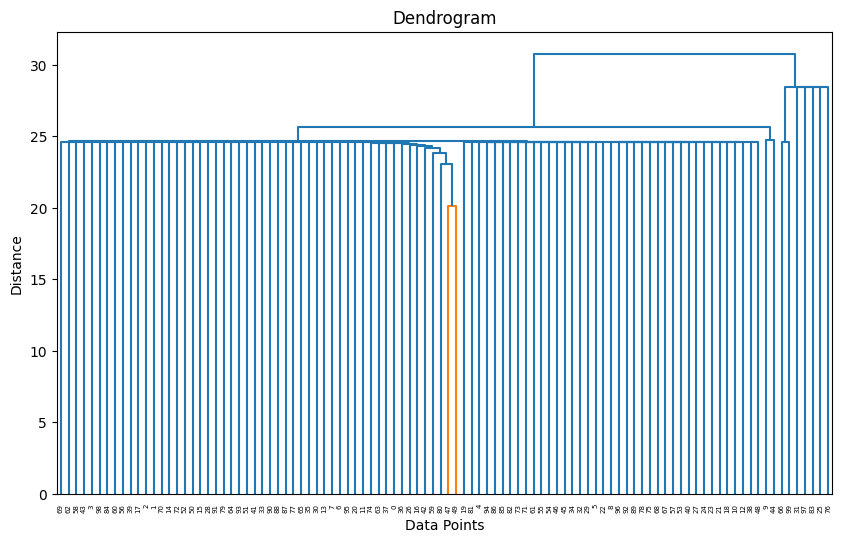

In [15]:
Z = linkage(X_scaled,method='ward')
plt.figure(figsize=(10,6))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [18]:
model = AgglomerativeClustering(n_clusters = 2)
clusters = model.fit_predict(X_scaled)
df['Cluster']=clusters

In [19]:
df['Cluster'].value_counts()

Cluster
1    93
0     7
Name: count, dtype: int64

In [20]:
df.head()

,Quantity,UnitPrice,InvoiceNo_536532,InvoiceNo_536593,InvoiceNo_537159,InvoiceNo_538163,InvoiceNo_538449,InvoiceNo_538658,InvoiceNo_539000,InvoiceNo_540114,...,InvoiceDate_9/7/2011 12:04,InvoiceDate_9/9/2011 14:47,Country_Bahrain,Country_EIRE,Country_Finland,Country_Germany,Country_Norway,Country_Spain,Country_United Kingdom,Cluster
209268,24,0.85,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,1
207108,4,6.95,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,1
167085,4,0.65,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,1
471836,3,1.95,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,1
115865,2,9.95,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,1


In [21]:
pd.crosstab(df['UnitPrice'],df['Cluster'])

Cluster,0,1
UnitPrice,,
0.00,0,1
0.39,0,2
0.42,0,4
0.63,0,1
0.65,0,3
0.79,0,2
0.81,0,1
0.83,0,5
0.85,3,5
